In [1]:
# Se define la carpeta donde se conservarán las visualizaciones.

OUTPUT_FOLDER = "../submission"

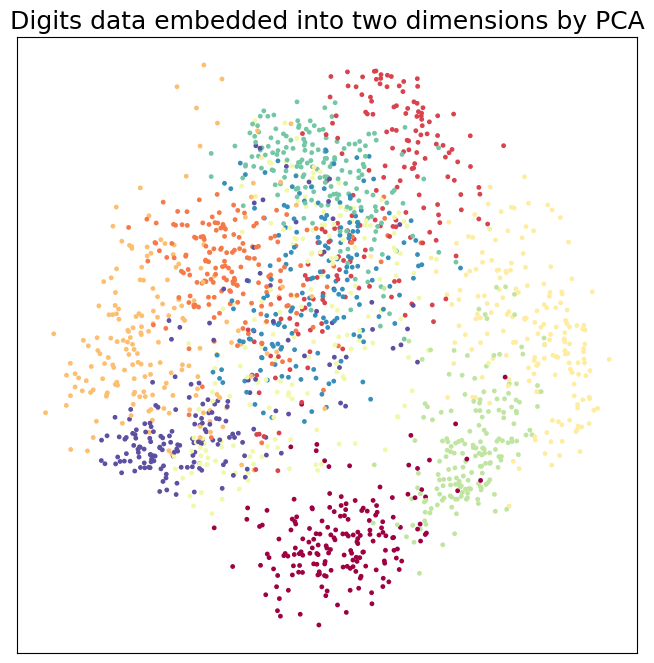

<Figure size 640x480 with 0 Axes>

In [2]:
# Se proyectan los dígitos con PCA para observar su estructura lineal.

def pca():

    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    from sklearn import decomposition
    from sklearn.datasets import load_digits

    digits = load_digits()

    X = digits.data
    y = digits.target

    pca = decomposition.PCA(n_components=2)
    principalComponents = pca.fit_transform(X)

    pca_data = np.vstack((principalComponents.T, y)).T
    pca_df = pd.DataFrame(
        data=pca_data, columns=("1st_principal", "2nd_principal", "label")
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    plt.scatter(
        pca_df["1st_principal"],
        pca_df["2nd_principal"],
        c=pca_df.label,
        cmap="Spectral",
        s=6,
    )
    plt.setp(ax, xticks=[], yticks=[])
    plt.title("Digits data embedded into two dimensions by PCA", fontsize=18)
    plt.show()
    plt.savefig(f"{OUTPUT_FOLDER}/digits_pca.png")


pca()

/Volumes/GitHub/classroom-vibecoding/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


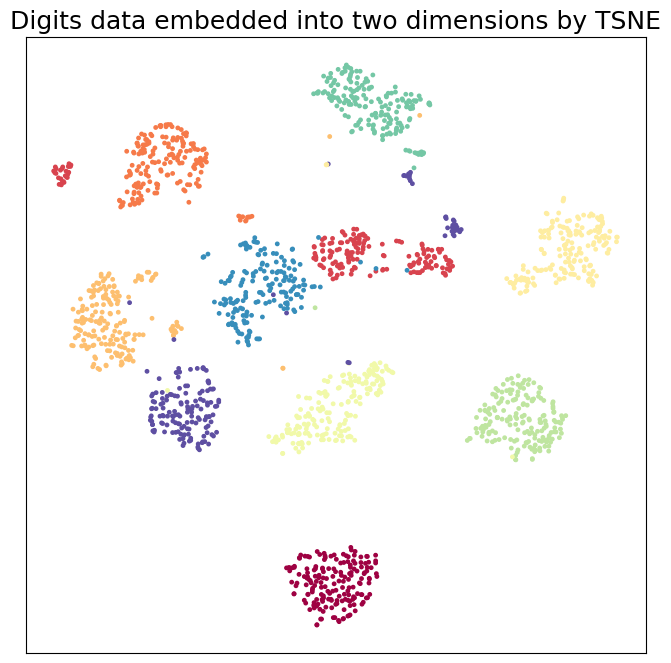

In [3]:
# Se proyectan los dígitos con t-SNE para comparar una estructura no lineal.

def tsne():

    import matplotlib.pyplot as plt
    import numpy as np
    import seaborn as sns
    import umap
    from sklearn import datasets, decomposition
    from sklearn.datasets import load_digits
    from sklearn.manifold import TSNE

    digits = load_digits()

    X = digits.data
    y = digits.target

    tsne = TSNE(n_components=2, random_state=0)
    embedding = tsne.fit_transform(X)

    fig, ax = plt.subplots(figsize=(8, 8))
    plt.scatter(embedding[:, 0], embedding[:, 1], c=y, cmap="Spectral", s=6)
    plt.setp(ax, xticks=[], yticks=[])
    plt.title("Digits data embedded into two dimensions by TSNE", fontsize=18)
    plt.savefig(f"{OUTPUT_FOLDER}/digits_tsne.png")


tsne()

/Volumes/GitHub/classroom-vibecoding/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


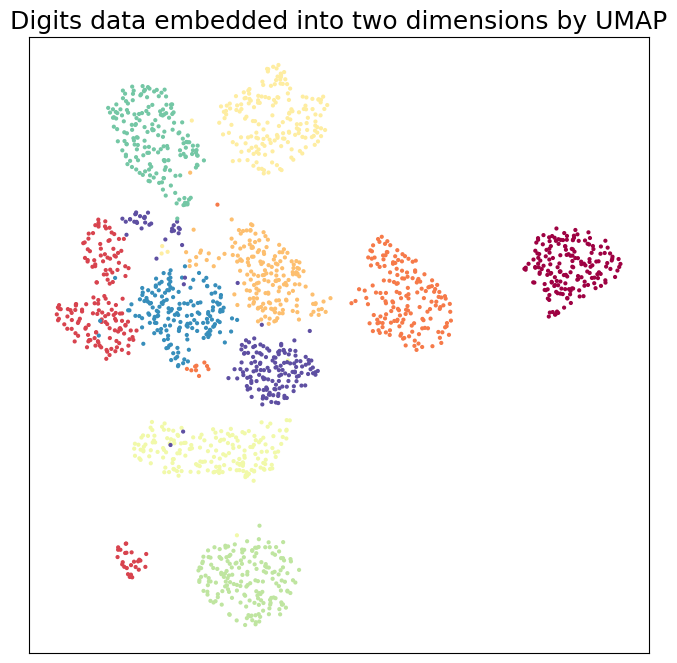

In [4]:
# Se aplica UMAP para comparar una reducción no lineal de dimensionalidad.
def umap():

    import matplotlib.pyplot as plt
    import numpy as np
    import umap
    from sklearn import datasets, decomposition
    from sklearn.datasets import load_digits

    digits = load_digits()

    X = digits.data
    y = digits.target

    reducer = umap.UMAP(random_state=42, min_dist=0.8)
    embedding = reducer.fit_transform(digits.data)

    fig, ax = plt.subplots(figsize=(8, 8))
    plt.scatter(embedding[:, 0], embedding[:, 1], c=y, cmap="Spectral", s=4)
    plt.setp(ax, xticks=[], yticks=[])
    plt.title("Digits data embedded into two dimensions by UMAP", fontsize=18)
    plt.savefig(f"{OUTPUT_FOLDER}/digits_umap.png")


umap()

In [5]:
# ¿Cuántas componentes principales conservan suficiente información para clasificar el dígito, no sólo para verse bien en un gráfico?

import numpy as np
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X_train, X_test, y_train, y_test = train_test_split(
    digits.data,
    digits.target,
    test_size=0.5,
    random_state=0,
    stratify=digits.target,
)

component_counts = [2, 5, 10, 20, 30, 40, 64]
component_rows = []
for k in component_counts:
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=k)),
        ("classifier", LogisticRegression(max_iter=1000)),
    ])
    pipeline.fit(X_train, y_train)
    test_accuracy = pipeline.score(X_test, y_test)
    explained_variance = pipeline.named_steps["pca"].explained_variance_ratio_.sum()
    component_rows.append({
        "k": k,
        "explained_variance": explained_variance,
        "test_accuracy": test_accuracy,
    })

pca_components_accuracy = pd.DataFrame(component_rows)
pca_components_accuracy

,k,explained_variance,test_accuracy
0,2,0.219732,0.543938
1,5,0.423248,0.812013
2,10,0.604982,0.880979
3,20,0.806500,0.935484
4,30,0.908787,0.942158
5,40,0.959915,0.952169
6,64,1.000000,0.963293


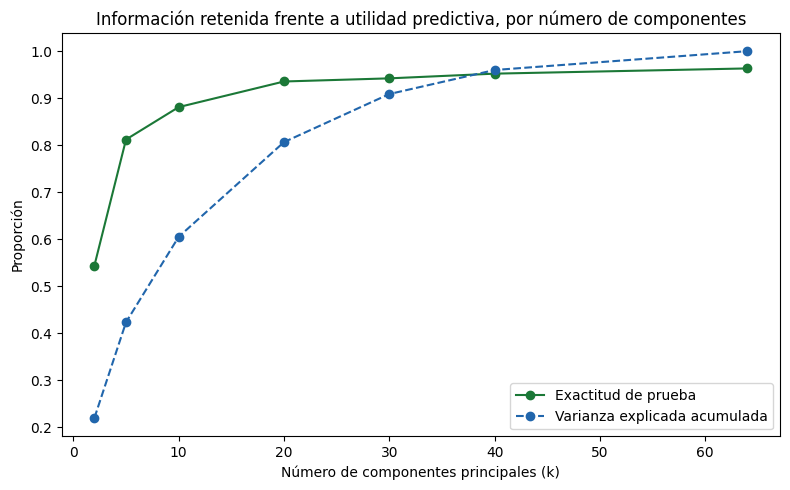

In [6]:
# La gráfica muestra si la exactitud de prueba sigue subiendo después de que la varianza explicada ya está casi completa.

import matplotlib.pyplot as plt

figure_components, axis_components = plt.subplots(figsize=(8, 5))
axis_components.plot(
    pca_components_accuracy["k"], pca_components_accuracy["test_accuracy"],
    marker="o", color="#1b7837", label="Exactitud de prueba",
)
axis_components.plot(
    pca_components_accuracy["k"], pca_components_accuracy["explained_variance"],
    marker="o", linestyle="--", color="#2166ac", label="Varianza explicada acumulada",
)
axis_components.set_xlabel("Número de componentes principales (k)")
axis_components.set_ylabel("Proporción")
axis_components.set_title("Información retenida frente a utilidad predictiva, por número de componentes")
axis_components.legend()
figure_components.tight_layout()
plt.show()

In [7]:
# Se conserva la tabla y la gráfica para que la elección de k pueda revisarse con evidencia predictiva, no sólo visual.

pca_components_accuracy.to_csv(f"{OUTPUT_FOLDER}/pca_components_accuracy.csv", index=False)
figure_components.savefig(f"{OUTPUT_FOLDER}/pca_components_accuracy.png", dpi=150, bbox_inches="tight")

# k entre 20 y 30 parece suficiente: la exactitud ya llega a 93.5 %-94.2 % (frente al 96.3 % con
# las 64 intensidades completas), mientras que subir a k=40 o k=64 añade menos de 3 puntos por el
# precio de retener más del doble de componentes. El PCA de dos componentes que ilustra H01 sólo
# captura 22.0 % de la varianza y clasificaría bien apenas 54.4 % de los casos: sirve para
# visualizar proximidades, no para decidir cuántas componentes bastan. t-SNE no tiene una
# transformación aplicable a observaciones nuevas (no hay un método para proyectar datos fuera de
# la muestra de ajuste), así que no se usa aquí como entrada de un predictor, a diferencia de PCA.
# Este resultado vale sólo para este dataset educativo de dígitos y esta partición; no generaliza
# a otro conjunto de imágenes.

In [8]:
# ¿UMAP, que sí admite proyectar observaciones nuevas, retiene tanta información predictiva como PCA con el mismo número de componentes?

import umap

umap_rows = []
for k in component_counts:
    reducer = umap.UMAP(n_components=k, random_state=42, min_dist=0.8)
    reducer.fit(X_train)
    train_embedding = reducer.transform(X_train)
    test_embedding = reducer.transform(X_test)

    classifier = LogisticRegression(max_iter=1000)
    classifier.fit(train_embedding, y_train)
    test_accuracy = classifier.score(test_embedding, y_test)

    umap_rows.append({"k": k, "test_accuracy": test_accuracy})

umap_components_accuracy = pd.DataFrame(umap_rows)
umap_components_accuracy

/Volumes/GitHub/classroom-vibecoding/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Volumes/GitHub/classroom-vibecoding/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Volumes/GitHub/classroom-vibecoding/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Volumes/GitHub/classroom-vibecoding/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Volumes/GitHub/classroom-vibecoding/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Volumes/GitHub/classroom-vibecoding/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Volumes/GitHub/classroom-vibecoding/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Volumes/GitHub/classroom-vibecoding/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,k,test_accuracy
0,2,0.889878
1,5,0.939933
2,10,0.949944
3,20,0.951057
4,30,0.951057
5,40,0.956618
6,64,0.954394


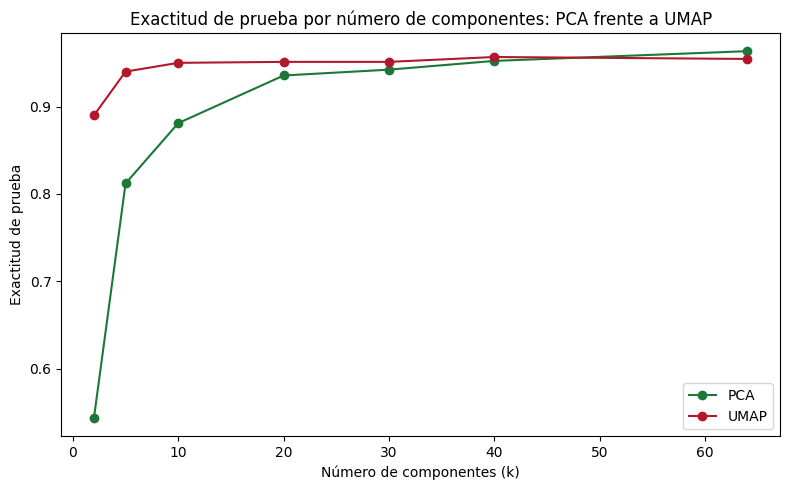

In [9]:
# La comparación muestra si una reducción no lineal con transformación a datos nuevos retiene más o menos información predictiva que PCA, componente por componente.

figure_comparison, axis_comparison = plt.subplots(figsize=(8, 5))
axis_comparison.plot(
    pca_components_accuracy["k"], pca_components_accuracy["test_accuracy"],
    marker="o", color="#1b7837", label="PCA",
)
axis_comparison.plot(
    umap_components_accuracy["k"], umap_components_accuracy["test_accuracy"],
    marker="o", color="#b2182b", label="UMAP",
)
axis_comparison.set_xlabel("Número de componentes (k)")
axis_comparison.set_ylabel("Exactitud de prueba")
axis_comparison.set_title("Exactitud de prueba por número de componentes: PCA frente a UMAP")
axis_comparison.legend()
figure_comparison.tight_layout()
plt.show()

In [10]:
# Se conserva la comparación con UMAP para que la elección entre reducciones lineales y no lineales tenga evidencia predictiva, no sólo visual.

umap_components_accuracy.to_csv(f"{OUTPUT_FOLDER}/umap_components_accuracy.csv", index=False)
figure_comparison.savefig(f"{OUTPUT_FOLDER}/components_accuracy_comparison.png", dpi=150, bbox_inches="tight")

# UMAP retiene mucha más información predictiva que PCA con pocas componentes: en k=2 ya alcanza
# 89.0 % de exactitud (frente al 54.4 % de PCA), y con k=5 llega a 94.0 %, cerca del 96.3 % que PCA
# sólo logra con sus 64 intensidades completas. A partir de k≈20 UMAP deja de mejorar (95.1 %-
# 95.7 %): la estructura no lineal que captura con pocas dimensiones no aporta más allá de ese
# punto en este dataset. Esta comparación es posible porque UMAP sí tiene una transformación
# aplicable a datos nuevos, a diferencia de t-SNE, que por eso no se incluye en esta evaluación
# fuera de muestra (ver la explicación de la sección de PCA). El resultado sigue siendo específico
# de este dataset y esta partición, y no mide tiempo de cómputo ni estabilidad de la proyección
# entre ejecuciones.